In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

LOT = 'lot_32'
LOT_DISPLAY = 'Lot 32'

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': 'white',
})

In [2]:
df_all = pd.read_csv('../parking_snapshots.csv')
df = df_all[df_all['lot_name'] == LOT].copy()

# UTC -> PST
df['collected_at'] = pd.to_datetime(df['collected_at'], utc=True)
df['collected_at_pst'] = df['collected_at'].dt.tz_convert('America/Los_Angeles')

# Derived columns
df['hour'] = df['collected_at_pst'].dt.hour
df['day_of_week'] = df['collected_at_pst'].dt.day_name()
df['date'] = df['collected_at_pst'].dt.date
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Back-calculate total capacity
mask = df['occupancy_pct'] < 100
df.loc[mask, 'total_spaces'] = (
    df.loc[mask, 'free_spaces'] / (1 - df.loc[mask, 'occupancy_pct'] / 100)
).round().astype(int)
capacity = int(df['total_spaces'].dropna().median())
df['total_spaces'] = df['total_spaces'].fillna(capacity)

# Summary
print(f"=== {LOT_DISPLAY} ===")
print(f"Capacity: {capacity} spaces")
print(f"Date range (PST): {df['collected_at_pst'].min()} → {df['collected_at_pst'].max()}")
print(f"Total snapshots: {len(df):,}")
print(f"Unique dates: {df['date'].nunique()}")

=== Lot 32 ===
Capacity: 258 spaces
Date range (PST): 2026-01-22 08:08:20.571202-08:00 → 2026-02-11 19:01:48.717543-08:00
Total snapshots: 2,327
Unique dates: 21


## 1. Daily Occupancy Time Series

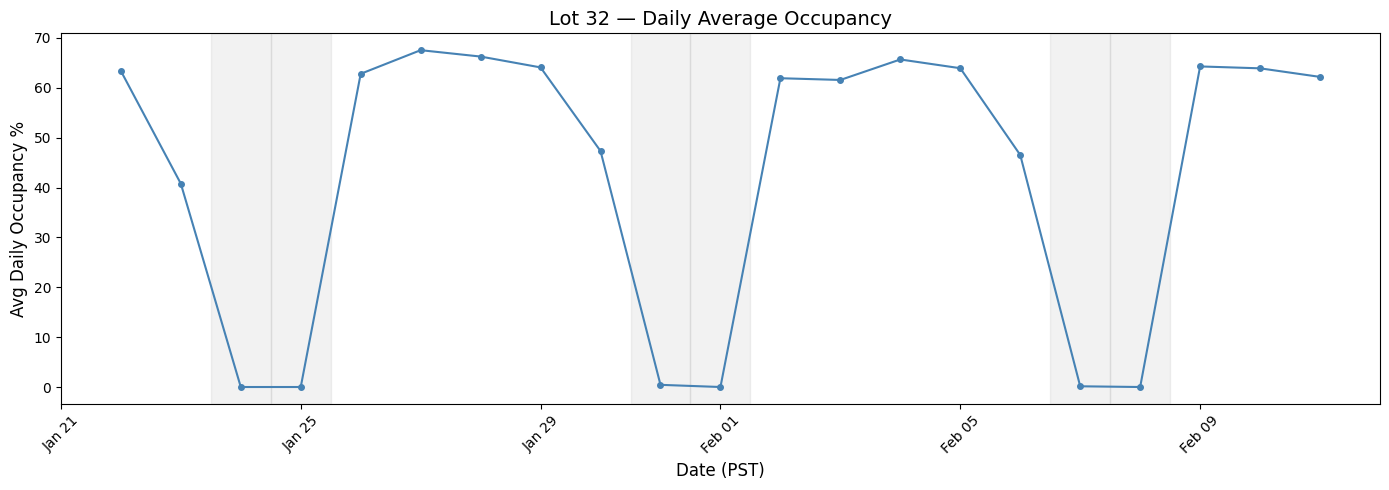

In [3]:
daily = df.groupby('date')['occupancy_pct'].mean().reset_index()
daily['date'] = pd.to_datetime(daily['date'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['date'], daily['occupancy_pct'], marker='o', markersize=4,
        color='steelblue', linewidth=1.5)

# Shade weekends
for d in daily['date']:
    if d.weekday() >= 5:  # Sat=5, Sun=6
        ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12),
                   color='gray', alpha=0.1)

ax.set_ylabel('Avg Daily Occupancy %')
ax.set_xlabel('Date (PST)')
ax.set_title(f'{LOT_DISPLAY} — Daily Average Occupancy')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Hourly Pattern (Weekday vs Weekend)

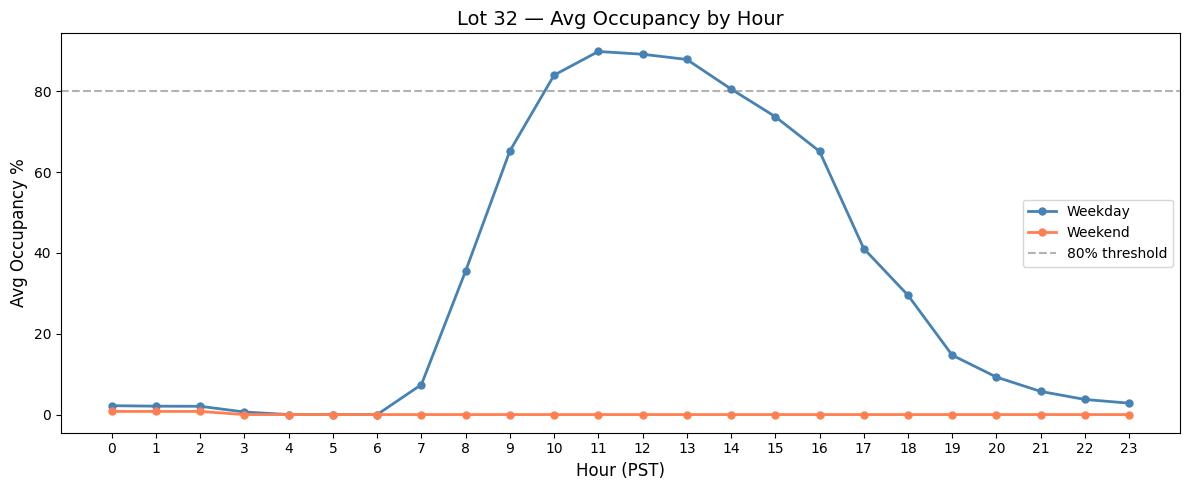

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

for is_wknd, label, color in [(False, 'Weekday', 'steelblue'), (True, 'Weekend', 'coral')]:
    subset = df[df['is_weekend'] == is_wknd]
    hourly = subset.groupby('hour')['occupancy_pct'].mean()
    ax.plot(hourly.index, hourly.values, marker='o', markersize=5,
            label=label, color=color, linewidth=2)

ax.axhline(80, color='gray', linestyle='--', alpha=0.6, label='80% threshold')
ax.set_ylabel('Avg Occupancy %')
ax.set_xlabel('Hour (PST)')
ax.set_title(f'{LOT_DISPLAY} — Avg Occupancy by Hour')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 3. Day-of-Week Boxplot

/var/folders/zn/fdymfjf11cb1lvkx8_s0wqwh0000gn/T/ipykernel_41107/2922311143.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[d[:3] for d in day_order], patch_artist=True)


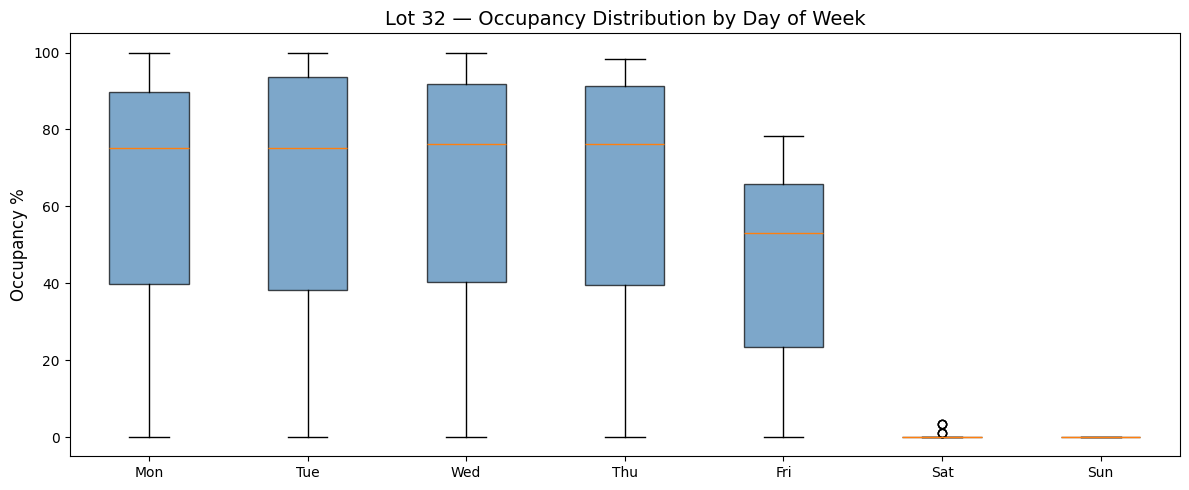

In [5]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
box_data = [df[df['day_of_week'] == d]['occupancy_pct'].values for d in day_order]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(box_data, labels=[d[:3] for d in day_order], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

ax.set_ylabel('Occupancy %')
ax.set_title(f'{LOT_DISPLAY} — Occupancy Distribution by Day of Week')
plt.tight_layout()
plt.show()

## 4. Occupancy Distribution

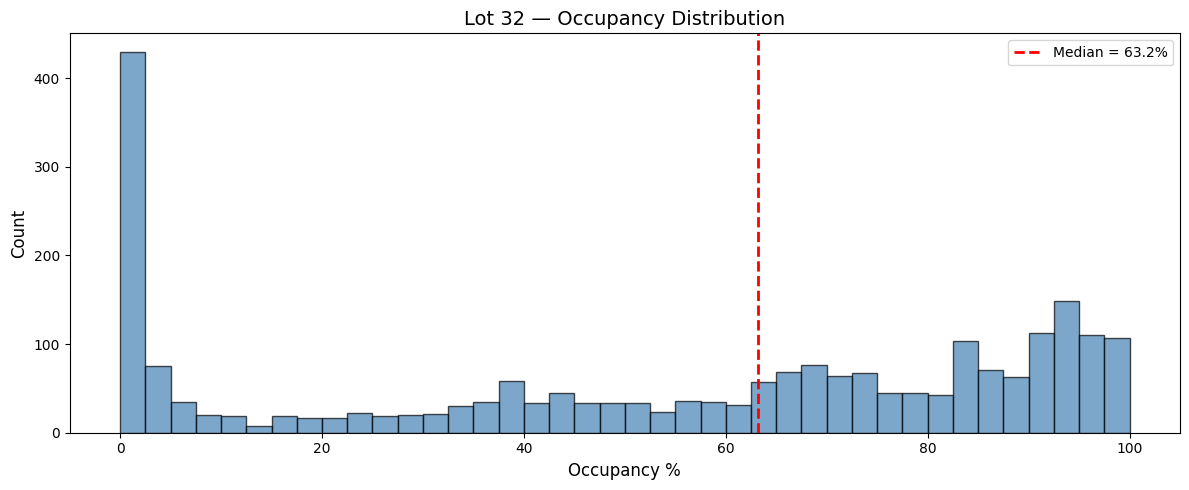

Key percentiles:
  25th: 13.4%
  50th: 63.2%
  75th: 85.7%
  90th: 95.0%
  95th: 97.3%


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['occupancy_pct'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
median_val = df['occupancy_pct'].median()
ax.axvline(median_val, color='red', linestyle='--', linewidth=2,
           label=f'Median = {median_val:.1f}%')
ax.set_xlabel('Occupancy %')
ax.set_ylabel('Count')
ax.set_title(f'{LOT_DISPLAY} — Occupancy Distribution')
ax.legend()
plt.tight_layout()
plt.show()

# Percentiles
pcts = [25, 50, 75, 90, 95]
print("Key percentiles:")
for p in pcts:
    val = np.percentile(df['occupancy_pct'], p)
    print(f"  {p}th: {val:.1f}%")

## 5. Peak Hours

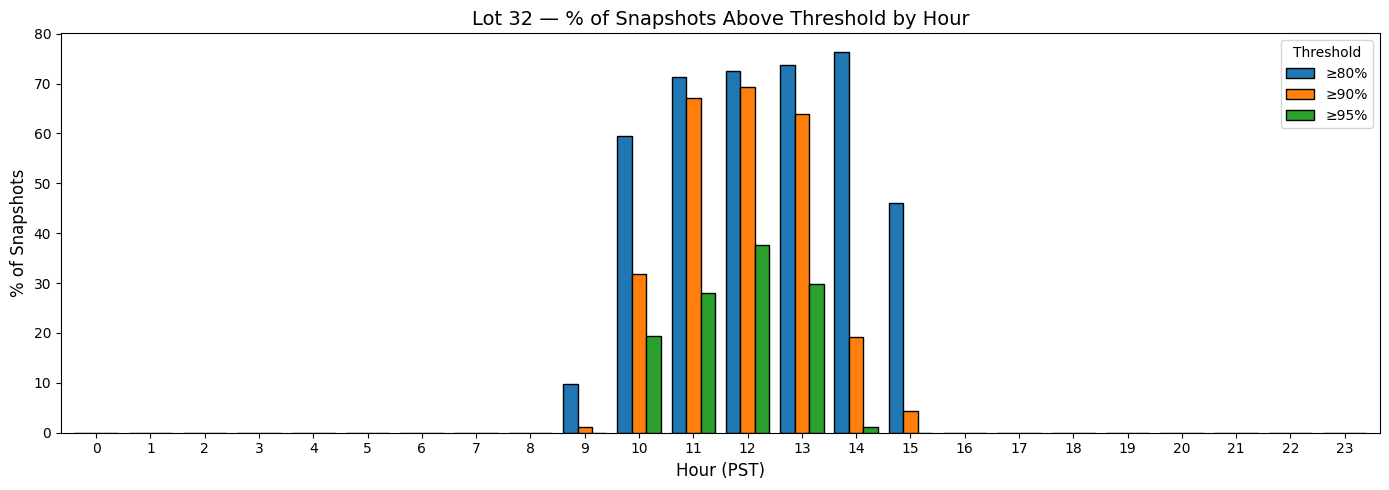

In [7]:
thresholds = [80, 90, 95]
records = []
for hour in sorted(df['hour'].unique()):
    sub = df[df['hour'] == hour]
    n = len(sub)
    for t in thresholds:
        pct = (sub['occupancy_pct'] >= t).sum() / n * 100 if n > 0 else 0
        records.append({'hour': hour, 'threshold': f'≥{t}%', 'pct': pct})

peak = pd.DataFrame(records)
pivot = peak.pivot(index='hour', columns='threshold', values='pct')
pivot = pivot[['≥80%', '≥90%', '≥95%']]

fig, ax = plt.subplots(figsize=(14, 5))
pivot.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_ylabel('% of Snapshots')
ax.set_xlabel('Hour (PST)')
ax.set_title(f'{LOT_DISPLAY} — % of Snapshots Above Threshold by Hour')
ax.legend(title='Threshold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Summary Stats

In [8]:
# Overall stats
capacity = int(df['total_spaces'].median())
stats = {
    'Capacity': capacity,
    'Mean Occupancy %': round(df['occupancy_pct'].mean(), 1),
    'Median Occupancy %': round(df['occupancy_pct'].median(), 1),
    'Std Dev': round(df['occupancy_pct'].std(), 1),
    'Min Occupancy %': round(df['occupancy_pct'].min(), 1),
    'Max Occupancy %': round(df['occupancy_pct'].max(), 1),
    'Avg Free Spaces': round(df['free_spaces'].mean(), 1),
    'Total Snapshots': len(df),
}
print(f"=== {LOT_DISPLAY} Summary ===")
for k, v in stats.items():
    print(f"  {k}: {v}")

# Weekday vs Weekend comparison
print(f"\n=== Weekday vs Weekend ===")
comparison = df.groupby('is_weekend').agg(
    mean_occ=('occupancy_pct', 'mean'),
    median_occ=('occupancy_pct', 'median'),
    std_occ=('occupancy_pct', 'std'),
    avg_free=('free_spaces', 'mean'),
    snapshots=('occupancy_pct', 'count'),
).round(1)
comparison.index = ['Weekday', 'Weekend']
print(comparison.to_string())

=== Lot 32 Summary ===
  Capacity: 258
  Mean Occupancy %: 53.0
  Median Occupancy %: 63.2
  Std Dev: 35.8
  Min Occupancy %: 0.0
  Max Occupancy %: 100.0
  Avg Free Spaces: 121.2
  Total Snapshots: 2327

=== Weekday vs Weekend ===
         mean_occ  median_occ  std_occ  avg_free  snapshots
Weekday      60.3        68.2     31.9     102.4       2045
Weekend       0.0         0.0      0.4     257.9        282
